In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt

In [7]:
batch_size = 128
latent_dim = 20
epochs = 20
lr = 1e-3
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 26.4M/26.4M [00:08<00:00, 2.96MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 46.5kB/s]
100%|██████████| 4.42M/4.42M [00:11<00:00, 381kB/s] 
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.2MB/s]


In [18]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        self.encoder_fc = nn.Linear(64 * 7 * 7, latent_dim)
        self.decoder_fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        latent = self.encoder_fc(encoded.view(encoded.size(0), -1))
        decoded = self.decoder_fc(latent).view(x.size(0), 64, 7, 7)
        return self.decoder(decoded)

model = Autoencoder(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
recon_loss = nn.BCELoss()

In [19]:
print("Training on device:", device)
model = model.to(device)
model.train()
for epoch in range(epochs):
    total_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_data = model(data)
        loss = recon_loss(recon_data, data)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch + 1}/{epochs}], Loss: {avg_loss:.4f}')

Training on device: mps
Epoch [1/20], Loss: 0.3308
Epoch [2/20], Loss: 0.2850
Epoch [3/20], Loss: 0.2801
Epoch [4/20], Loss: 0.2777
Epoch [5/20], Loss: 0.2761
Epoch [6/20], Loss: 0.2749
Epoch [7/20], Loss: 0.2740
Epoch [8/20], Loss: 0.2733
Epoch [9/20], Loss: 0.2727
Epoch [10/20], Loss: 0.2723
Epoch [11/20], Loss: 0.2719
Epoch [12/20], Loss: 0.2715
Epoch [13/20], Loss: 0.2712
Epoch [14/20], Loss: 0.2710
Epoch [15/20], Loss: 0.2707
Epoch [16/20], Loss: 0.2705
Epoch [17/20], Loss: 0.2703
Epoch [18/20], Loss: 0.2701
Epoch [19/20], Loss: 0.2699
Epoch [20/20], Loss: 0.2698


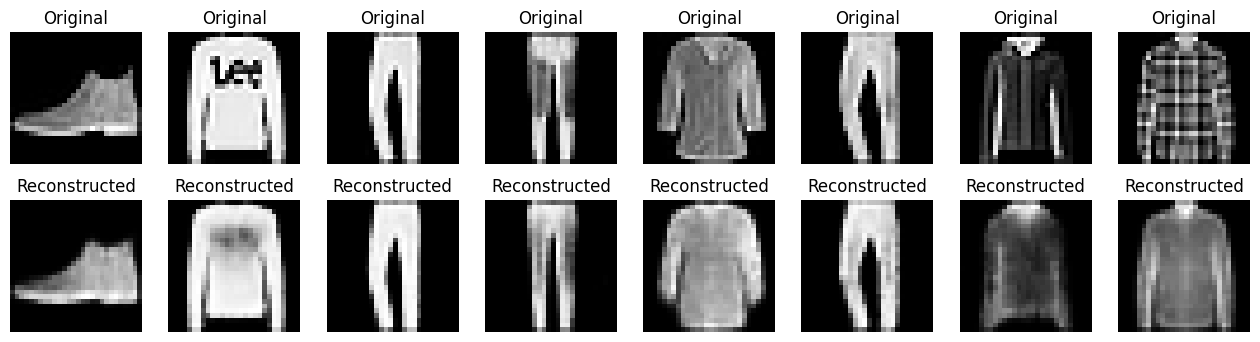

In [20]:
model.eval()
with torch.no_grad():
    for batch_idx, (data, _) in enumerate(test_loader):
        data = data.to(device)
        recon_data = model(data)
        break  # Only process the first batch for visualization

n_show = 8
plt.figure(figsize=(16, 4))
for i in range(n_show):
    # Original images
    plt.subplot(2, n_show, i + 1)
    plt.imshow(data[i].cpu().squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed images
    plt.subplot(2, n_show, i + 1 + n_show)
    plt.imshow(recon_data[i].cpu().squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()